In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from datetime import datetime

In [2]:
df = pd.read_csv("../data/DEvideos_clean.csv", keep_default_na=False)

In [3]:
# Convertir fechas a datetime (necesario para cálculos)
df['publish_time'] = pd.to_datetime(df['publish_time']).dt.tz_localize(None)
# Nota: Como para nuestros propositos no necesitamos el timezone, no lo consideramos
df['trending_date'] = pd.to_datetime(df['trending_date'], format="%y.%d.%m")

In [4]:
print(f"Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas")
df.head()

Dataset cargado: 40840 filas, 20 columnas


,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,state,lat,lon,geometry
0,LgVi6y5QIjM,2017-11-14,Sing zu Ende! | Gesangseinlagen vom Feinsten |...,inscope21,24,2017-11-13 17:08:49,"inscope21|""sing zu ende""|""gesangseinlagen""|""ge...",252786,35885,230,1539,https://i.ytimg.com/vi/LgVi6y5QIjM/default.jpg,False,False,False,Heute gibt es mal wieder ein neues Format... w...,Schleswig Holstein,54.783748,9.433315,POINT (9.433315388 54.78374778)
1,Bayt7uQith4,2017-11-14,Kinder ferngesteuert im Kiosk! Erwachsene abzo...,LUKE! Die Woche und ich,23,2017-11-12 22:30:01,"Kinder|""ferngesteuert""|""Kinder ferngesteuert""|...",797196,53576,302,1278,https://i.ytimg.com/vi/Bayt7uQith4/default.jpg,False,False,False,Kinder ferngesteuert! Kinder lassen sich sooo ...,Nordrhein Westfalen,52.029988,8.530011,POINT (8.530011351000001 52.02998822)
2,1ZAPwfrtAFY,2017-11-14,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13 07:30:00,"last week tonight trump presidency|""last week ...",2418783,97190,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John...",Saarland,49.250390,6.970003,POINT (6.970003213 49.25039044)
3,AHtypnRk7JE,2017-11-14,Das Fermi-Paradoxon,100SekundenPhysik,27,2017-11-12 15:00:01,"Physik|""Wissenschaft""|""Technik""|""Science-Ficti...",380247,31821,458,1955,https://i.ytimg.com/vi/AHtypnRk7JE/default.jpg,False,False,False,►Alle Videos: http://bit.ly/1fa7Tw3\n\n\n✚Snap...,Bayern,50.266607,10.966607,POINT (10.96660681 50.26660748)
4,ZJ9We4bjcg0,2017-11-14,18 SONGS mit Kelly MissesVlog (Sing-off),rezo,24,2017-11-12 13:10:36,"kelly|""missesvlog""|""kelly song""|""bausa""|""bausa...",822213,100684,2467,10244,https://i.ytimg.com/vi/ZJ9We4bjcg0/default.jpg,False,False,False,18 Song Mashup über den (veränderten) Beat von...,Berlin,52.521819,13.401549,POINT (13.40154862 52.52181866)


### Mapeo de categorías (desde el JSON)

Usaremos el archivo `DE_category_id.json` para mapear cada `category_id` a su respectiva categoría para la visualización, pero se conserva el id original para el modelo

In [5]:
# Cargar el archivo JSON de categorías
with open('../data/DE_category_id.json', 'r') as f:
    cat_data = json.load(f)

# Crear un diccionario: id -> nombre
cat_dict = {}
for item in cat_data['items']:
    cat_dict[item['id']] = item['snippet']['title']

# Mapear al dataframe
df['category_name'] = df['category_id'].astype(str).map(cat_dict)

# Verificar que no haya NaN en category_name (por si algún id no está en el JSON)
print(f"Categorías únicas mapeadas: {df['category_name'].nunique()}")
print(df['category_name'].value_counts().head(10))

Categorías únicas mapeadas: 17
category_name
Entertainment       15292
People & Blogs       5988
News & Politics      2935
Sports               2752
Comedy               2534
Film & Animation     2376
Music                2372
Howto & Style        1745
Gaming               1565
Autos & Vehicles      873
Name: count, dtype: int64


### Feature Engineering (Creación de variables derivadas)

Aquí generamos las columnas que serán candidatas a variables independientes para el modelo, así como otras para responder a preguntas de negocio

In [6]:
# 4.1 Días transcurridos hasta entrar en tendencia (clave para predecir vistas)
df['days_to_trend'] = (df['trending_date'] - df['publish_time']).dt.days

# 4.2 Hora de publicación (extraer hora y día de la semana)
df['hour_published'] = df['publish_time'].dt.hour
df['weekday_published'] = df['publish_time'].dt.dayofweek  # 0=Lunes, 6=Domingo

# 4.3 Número de etiquetas (tags) - Ya limpiamos nulos, así que usamos string vacío si no hay
df['num_tags'] = df['tags'].apply(lambda x: len(x.split('|')) if isinstance(x, str) and x != '' else 0)

# 4.4 Longitud del título
df['title_length'] = df['title'].str.len()

# 4.5 Longitud de la descripción
df['desc_length'] = df['description'].str.len()

# 4.6 Indicador de si los comentarios están desactivados (booleano)
df['comments_disabled'] = df['comments_disabled'].astype(int)

# 4.7 Indicador de si las calificaciones están desactivadas (booleano)
df['ratings_disabled'] = df['ratings_disabled'].astype(int)


In [7]:
# 4.8 Ratio de likes y dislikes

# Calcular el ratio. Donde dislikes = 0, el resultado es infinito.
df['likes/dislikes'] = df['likes'] / df['dislikes']

# Reemplazar infinitos (división por cero) por NaN
# Esto es lo más seguro para cálculos estadísticos (media, mediana, boxplots)
df['likes/dislikes'] = df['likes/dislikes'].replace([np.inf, -np.inf], np.nan)

# Ver cuántos quedaron como NaN (son los que tienen dislikes = 0)
nan_ratio_count = df['likes/dislikes'].isna().sum()
print(f"Videos con dislikes = 0 (ratio infinito): {nan_ratio_count} ({nan_ratio_count/len(df)*100:.2f}%)")

# Para las visualizaciones y responder Q3, si queremos incluirlos, 
# podemos reemplazar temporalmente NaN por un número muy alto (ej. el máximo + 1)
# PERO para no distorsionar la media, dejamos NaN y al hacer groupby usamos skipna=True.
# Lo dejamos como NaN por ahora.

Videos con dislikes = 0 (ratio infinito): 931 (2.28%)


In [8]:
# Verificar las nuevas columnas
print("Nuevas columnas creadas:")
new_columns = ['days_to_trend', 'hour_published', 'weekday_published', 'num_tags', 'title_length', 'desc_length', 'likes/dislikes']
df[new_columns].head(10)

Nuevas columnas creadas:


,days_to_trend,hour_published,weekday_published,num_tags,title_length,desc_length,likes/dislikes
0,0,17,0,16,56,636,156.021739
1,1,22,6,27,84,726,177.403974
2,0,7,0,4,62,630,15.813537
3,1,15,6,9,19,259,69.478166
4,1,13,6,5,40,357,40.812323
5,0,1,0,0,56,644,10.449324
6,0,11,0,17,28,174,61.771626
7,0,18,0,13,71,630,106.497041
8,1,11,6,24,42,450,29.742105
9,0,15,0,16,64,812,107.931818


In [9]:
df[new_columns].describe()

,days_to_trend,hour_published,weekday_published,num_tags,title_length,desc_length,likes/dislikes
count,40840.000000,40840.000000,40840.000000,40840.000000,40840.000000,40840.000000,39909.000000
mean,0.850416,14.361949,3.085602,17.897356,55.407542,980.669907,37.160170
std,19.621604,5.036252,1.980553,12.132055,21.457093,914.196961,52.475259
min,-1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,0.000000,11.000000,1.000000,8.000000,39.000000,308.000000,9.373303
50%,0.000000,15.000000,3.000000,17.000000,53.000000,727.000000,21.682403
75%,1.000000,18.000000,5.000000,26.000000,71.000000,1348.000000,45.514286
max,2045.000000,23.000000,6.000000,97.000000,100.000000,5287.000000,1413.520000


### Análisis Exploratorio (EDA) para responder preguntas de negocio (Q1-Q7)

In [10]:
# Configurar estilo
sns.set_style("whitegrid")

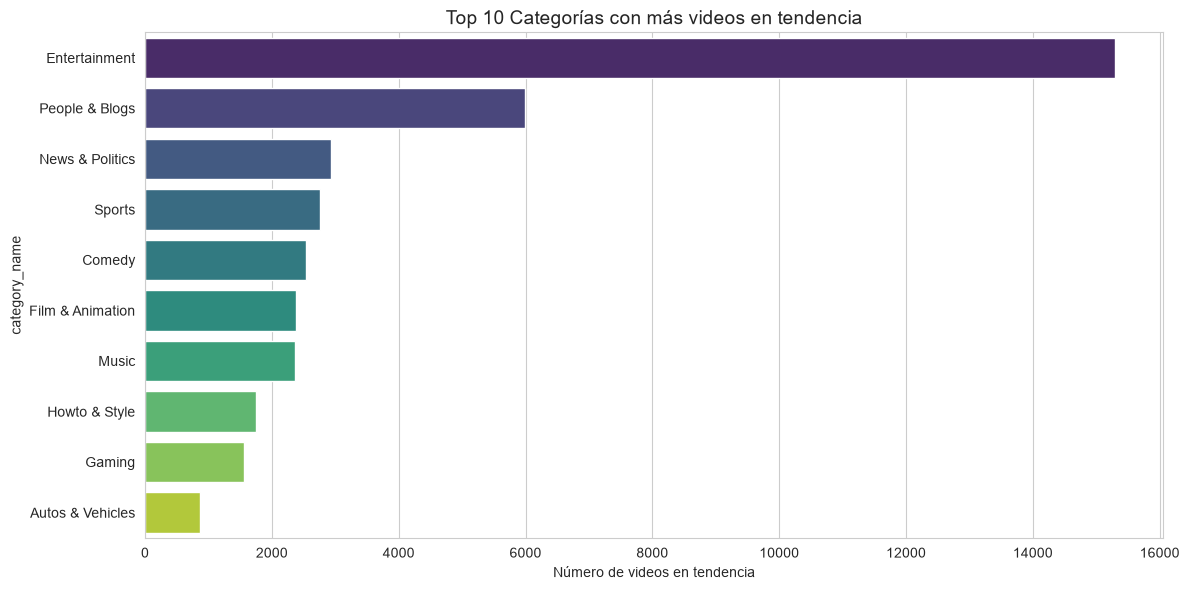

In [11]:
# --- Q1: Categorías con mayor tendencia (frecuencia) ---
plt.figure(figsize=(12, 6))
top_categories = df['category_name'].value_counts().head(10)
sns.barplot(x=top_categories.values, y=top_categories.index, hue=top_categories.index, palette='viridis', legend=False)
plt.title('Top 10 Categorías con más videos en tendencia', fontsize=14)
plt.xlabel('Número de videos en tendencia')
plt.tight_layout()
plt.show()

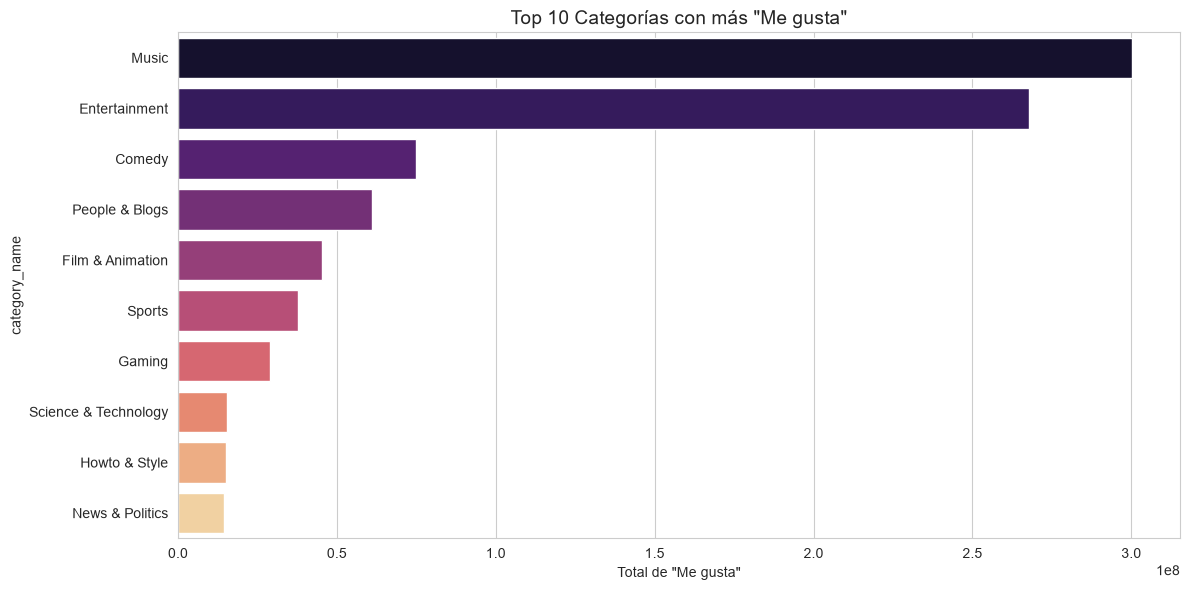

In [12]:
# --- Q2: Categorías que más gustan (suma de likes) ---
likes_by_cat = df.groupby('category_name')['likes'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=likes_by_cat.values, y=likes_by_cat.index, hue=likes_by_cat.index, palette='magma', legend=False)
plt.title('Top 10 Categorías con más "Me gusta"', fontsize=14)
plt.xlabel('Total de "Me gusta"')
plt.tight_layout()
plt.show()

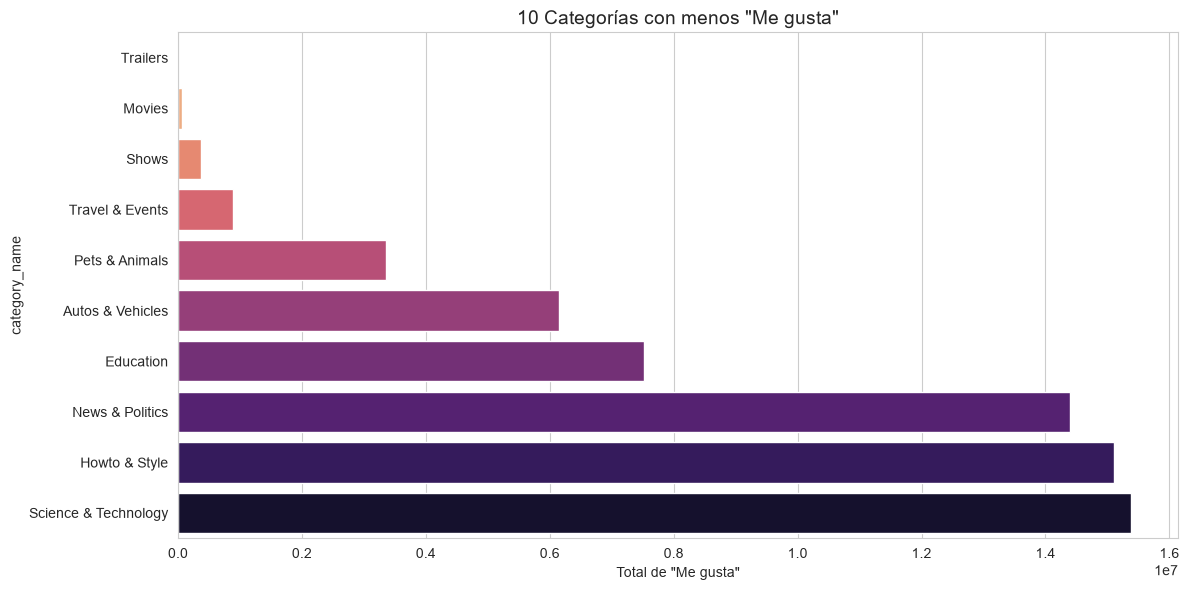

In [36]:
likes_by_cat_r = df.groupby('category_name')['likes'].sum().sort_values(ascending=True).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=likes_by_cat_r.values, y=likes_by_cat_r.index, hue=likes_by_cat_r.index, palette='magma_r', legend=False)
plt.title('10 Categorías con menos "Me gusta"', fontsize=14)
plt.xlabel('Total de "Me gusta"')
plt.tight_layout()
plt.show()

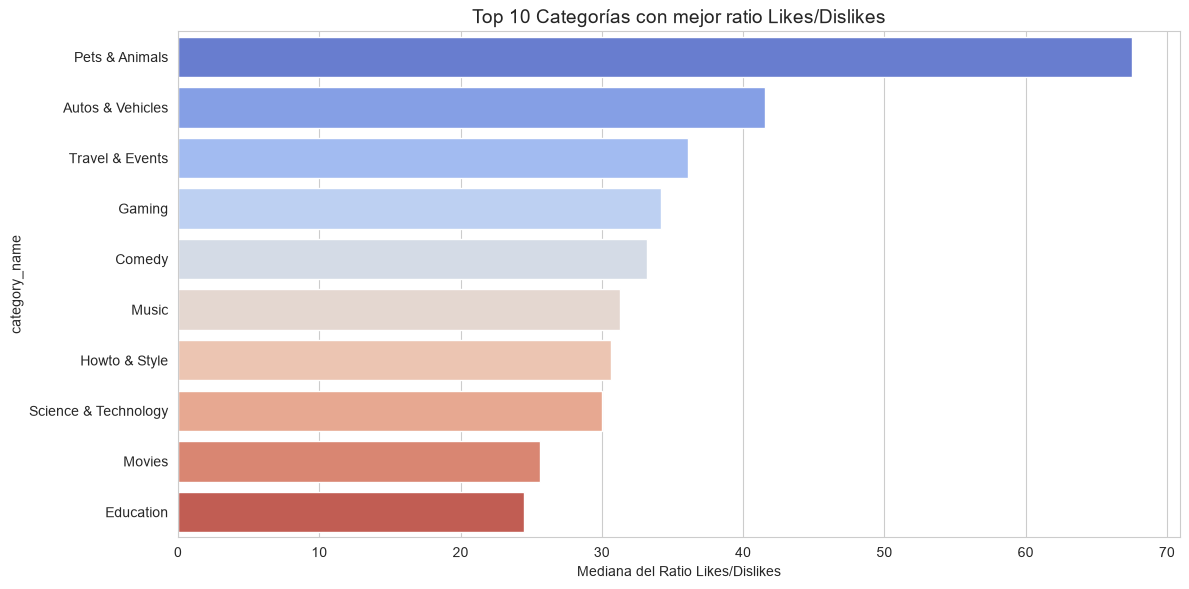

In [13]:
# --- Q3: Categorías con mejor ratio Likes/dislikes ---
# Usamos la mediana para evitar que outliers distorsionen (más robusto)
ratio_by_cat = df.groupby('category_name')['likes/dislikes'].median().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=ratio_by_cat.values, y=ratio_by_cat.index, hue=ratio_by_cat.index, palette='coolwarm', legend=False)
plt.title('Top 10 Categorías con mejor ratio Likes/Dislikes', fontsize=14)
plt.xlabel('Mediana del Ratio Likes/Dislikes')
plt.tight_layout()
plt.show()

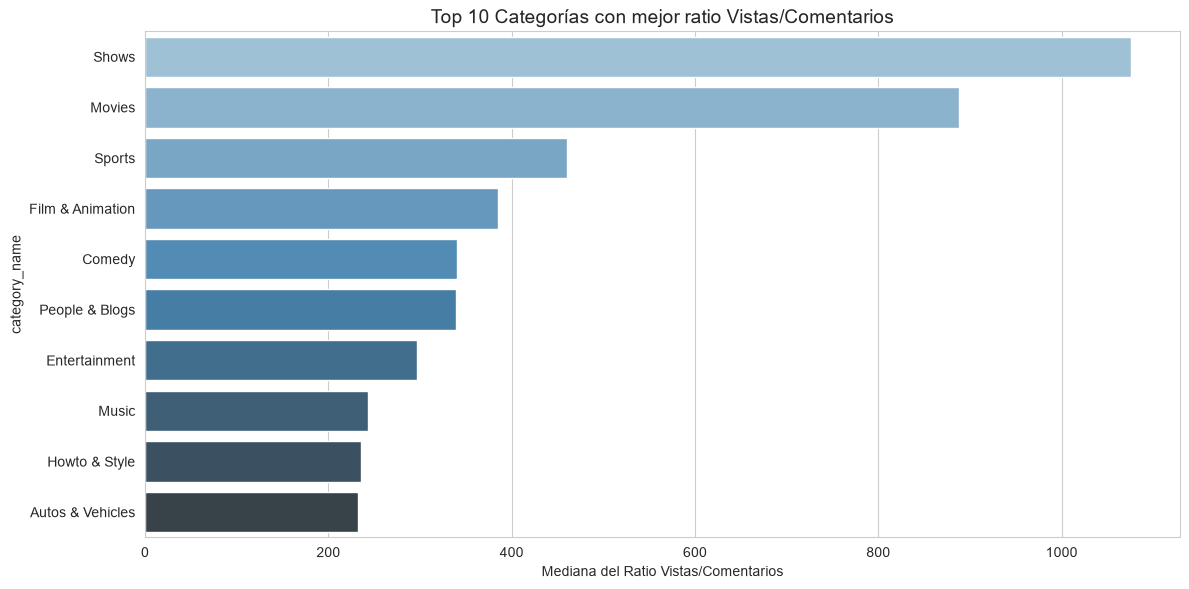

In [14]:
# --- Q4: Categorías con mejor ratio Views/Comments ---
# Calculamos el ratio vistas/comentarios
df['views/comments'] = df['views'] / df['comment_count']
# Reemplazar infinitos (comment_count=0) por NaN
df['views/comments'] = df['views/comments'].replace([np.inf, -np.inf], np.nan)

ratio_vc_by_cat = df.groupby('category_name')['views/comments'].median().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=ratio_vc_by_cat.values, y=ratio_vc_by_cat.index, hue=ratio_vc_by_cat.index, palette='Blues_d', legend=False)
plt.title('Top 10 Categorías con mejor ratio Vistas/Comentarios', fontsize=14)
plt.xlabel('Mediana del Ratio Vistas/Comentarios')
plt.tight_layout()
plt.show()

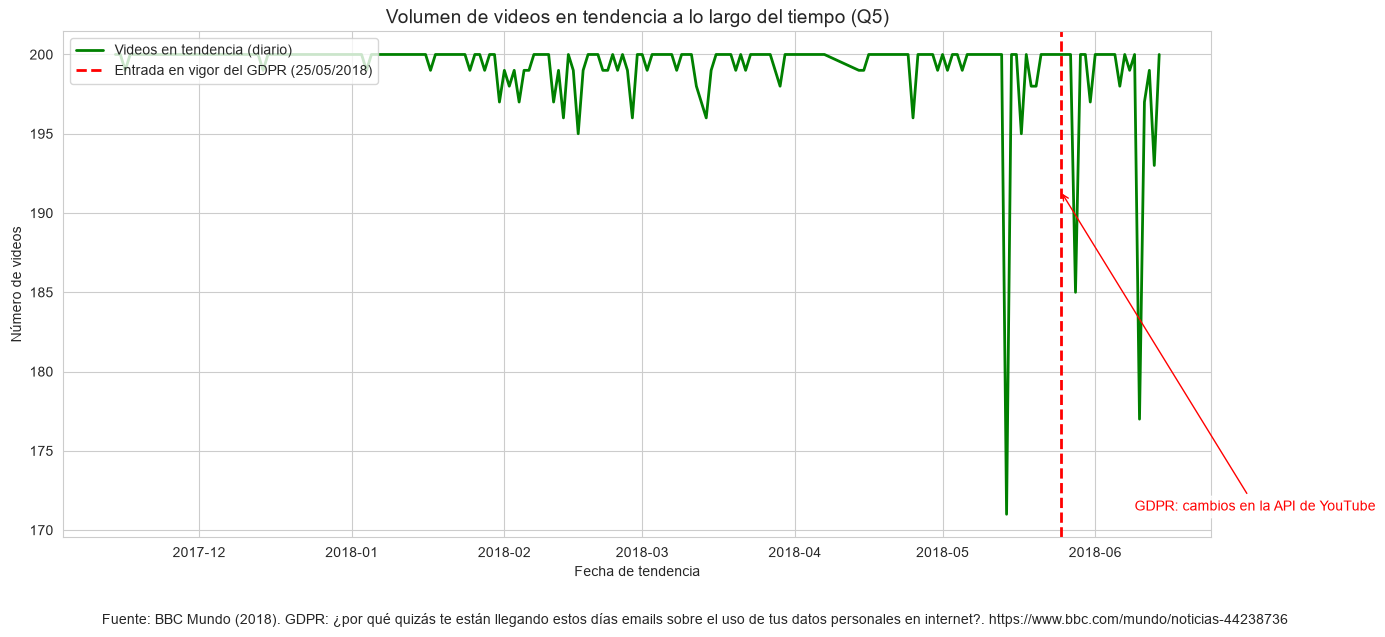

In [15]:
trends_by_date = df.groupby('trending_date')['video_id'].count()
plt.figure(figsize=(14, 6))

plt.plot(trends_by_date.index, trends_by_date.values, 
         color='green', linewidth=2, label='Videos en tendencia (diario)')

gdpr_date = pd.Timestamp('2018-05-25')
plt.axvline(x=gdpr_date, color='red', linestyle='--', linewidth=2, 
            label='Entrada en vigor del GDPR (25/05/2018)')

plt.annotate('GDPR: cambios en la API de YouTube',
             xy=(gdpr_date, plt.ylim()[1] * 0.95),
             xytext=(gdpr_date + pd.Timedelta(days=15), plt.ylim()[1] * 0.85),
             arrowprops=dict(arrowstyle='->', color='red'),
             fontsize=10, color='red',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.title('Volumen de videos en tendencia a lo largo del tiempo (Q5)', fontsize=14)
plt.xlabel('Fecha de tendencia')
plt.ylabel('Número de videos')
plt.legend(loc='upper left')

plt.figtext(0.5, -0.05, 
            'Fuente: BBC Mundo (2018). GDPR: ¿por qué quizás te están llegando estos días emails sobre el uso de tus datos personales en internet?. https://www.bbc.com/mundo/noticias-44238736',
            ha='center', fontsize=10, wrap=True)

plt.tight_layout()
plt.show()

Durante el análisis exploratorio de la evolución temporal del volumen de vídeos en tendencia, se observó un techo consistente en 200 vídeos diarios, correspondiente al límite máximo de la API de YouTube (Mitchell, 2018). Adicionalmente, se detectó una caída pronunciada en el volumen de registros alrededor de la quincena de mayo de 2018, con un pico mínimo de casi 170 vídeos. Este descenso se produjo antes de la entrada en vigor oficial del Reglamento General de Protección de Datos (GDPR) el 25 de mayo de 2018 (European Union, 2018). Esta anticipación se explica porque plataformas como YouTube suelen desplegar los cambios técnicos relacionados con el cumplimiento normativo de forma escalonada y anticipada para mitigar riesgos (BBC Mundo, 2018). Es probable que las modificaciones en la API (nuevas políticas de autenticación, restricciones de metadatos y límites de tasa) provocaran fallos intermitentes en el script de recolección durante los días previos a la fecha oficial. Posteriormente, tras la estabilización de la API, el volumen diario se estableció en un nuevo rango promedio de 176 a 185 vídeos, ligeramente inferior al techo original de 200. Este quiebre estructural será considerado una limitación del dataset en el modelado predictivo.

#### Fuentes
Mitchell, J. (2018). Trending YouTube Video Statistics. Kaggle. https://www.kaggle.com/datasets/datasnaek/youtube-new

BBC Mundo. (2018, May 24). GDPR: ¿por qué quizás te están llegando estos días emails sobre el uso de tus datos personales en internet?. https://www.bbc.com/mundo/noticias-44238736

European Union. (2018). General Data Protection Regulation (GDPR) (Regulation (EU) 2016/679). Official Journal of the European Union. https://eur-lex.europa.eu/eli/reg/2016/679/oj

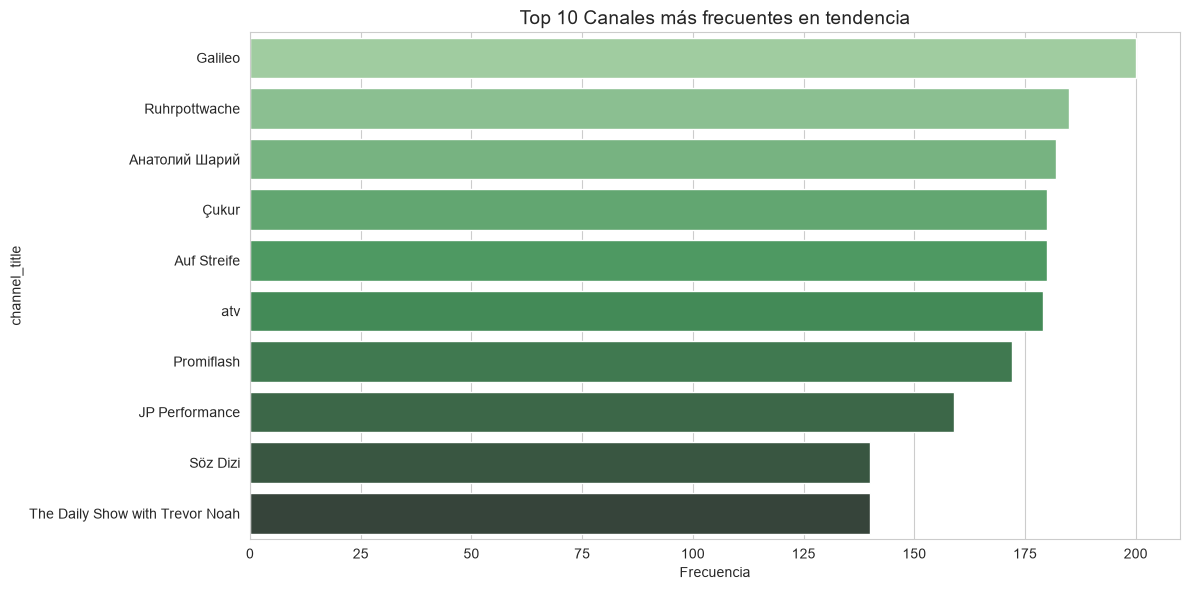

In [37]:
# --- Q6: Canales más y menos frecuentes en tendencia ---
plt.figure(figsize=(12, 6))

top_channels = df['channel_title'].value_counts().head(10)

sns.barplot(x=top_channels.values, y=top_channels.index, hue=top_channels.index, palette='Greens_d', legend=False)
plt.title('Top 10 Canales más frecuentes en tendencia', fontsize=14)
plt.xlabel('Frecuencia')
plt.tight_layout()
plt.show()

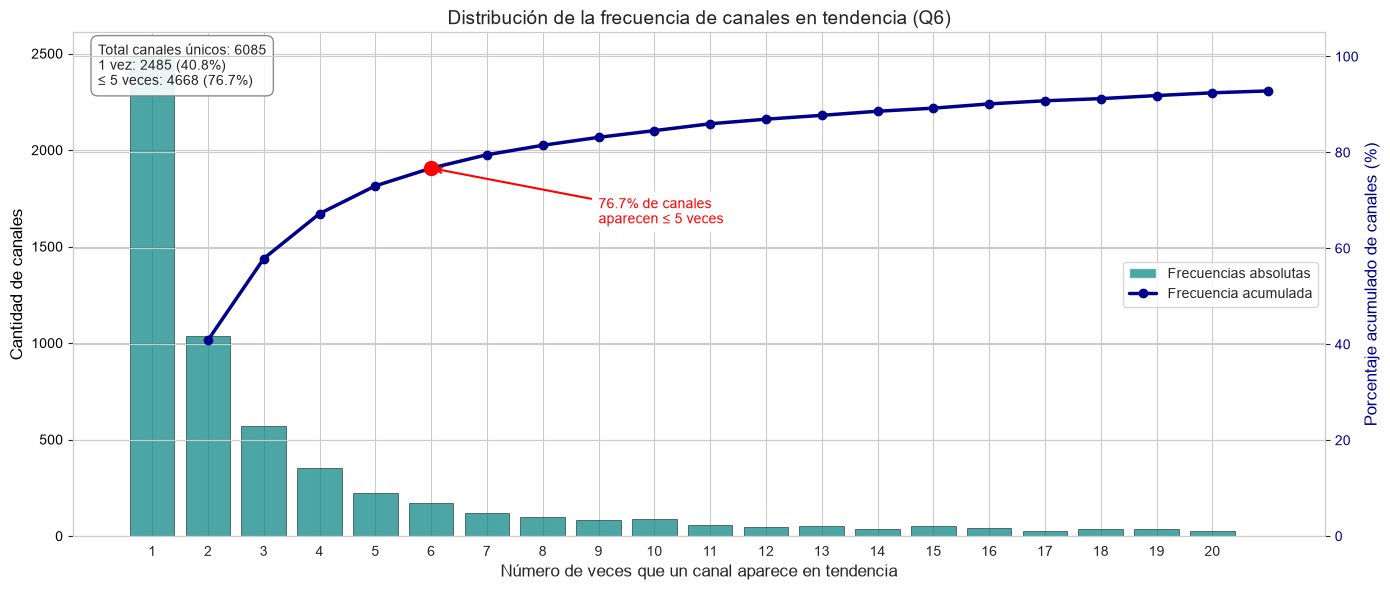

In [17]:
# --- Análisis de frecuencia de canales ---
channel_freq = df['channel_title'].value_counts()

# 1. Estadísticas descriptivas
unique_channels = len(channel_freq)
channels_once = (channel_freq == 1).sum()
channels_five_or_less = (channel_freq <= 5).sum()

pct_once = (channels_once / unique_channels) * 100
pct_five_or_less = (channels_five_or_less / unique_channels) * 100

# --- Preparar datos para el gráfico ---
# Frecuencias de los canales (mostramos hasta 20)
freq_counts = channel_freq.value_counts().sort_index()
freq_counts_filtered = freq_counts[freq_counts.index <= 20]

# Calcular la frecuencia acumulada (porcentaje)
cumulative_pct = (freq_counts_filtered.cumsum() / unique_channels) * 100

# --- Configurar la figura con dos ejes ---
fig, ax1 = plt.subplots(figsize=(14, 6))

# --- 1. Histograma de barras (Eje izquierdo) ---
x_vals = freq_counts_filtered.index.values

bars = ax1.bar(x_vals.astype(str), 
               freq_counts_filtered.values, 
               color='teal', alpha=0.7, edgecolor='black', linewidth=0.5)

# Configurar el eje izquierdo
ax1.set_xlabel('Número de veces que un canal aparece en tendencia', fontsize=12)
ax1.set_ylabel('Cantidad de canales', fontsize=12, color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.set_xticks(x_vals.astype(str))
ax1.set_xticklabels(x_vals)

# --- 2. Línea de frecuencia acumulada (Eje derecho) ---
ax2 = ax1.twinx()
ax2.plot(x_vals, cumulative_pct, marker='o', linestyle='-', linewidth=2.5, 
         color='darkblue', markersize=6, label='Frecuencia acumulada (%)')

# Resaltar el punto exacto en x=5 (76.7%)
# Encontrar el índice donde x_vals == 5
idx_5 = np.where(x_vals == 5)[0]
if len(idx_5) > 0:
    pct_at_5 = cumulative_pct.iloc[idx_5[0]]
    ax2.plot(5, pct_at_5, 'ro', markersize=10)  # Punto rojo grande
    # Anotación con flecha
    ax2.annotate(f'{pct_at_5:.1f}% de canales\naparecen ≤ 5 veces',
                 xy=(5, pct_at_5),
                 xytext=(8, pct_at_5 * 0.85),
                 arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
                 fontsize=10, color='red',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9))

# Configurar el eje derecho
ax2.set_ylabel('Porcentaje acumulado de canales (%)', fontsize=12, color='darkblue')
ax2.tick_params(axis='y', labelcolor='darkblue')
ax2.set_ylim(0, 105)  # Dejar un poco de margen arriba

# --- 3. Recuadro estadístico en la esquina superior izquierda (para no tapar la curva) ---
stats_text = (f"Total canales únicos: {unique_channels}\n"
              f"1 vez: {channels_once} ({pct_once:.1f}%)\n"
              f"≤ 5 veces: {channels_five_or_less} ({pct_five_or_less:.1f}%)")

ax1.text(0.02, 0.98, stats_text, 
         transform=ax1.transAxes, 
         fontsize=10, 
         verticalalignment='top', 
         horizontalalignment='left',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='gray'))

# --- 4. Títulos y leyenda ---
plt.title('Distribución de la frecuencia de canales en tendencia (Q6)', fontsize=14)

# Añadir una leyenda combinada (opcional, pero ayuda)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
# ax1 no tiene labels por defecto, así que creamos una manual
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='teal', alpha=0.7, label='Frecuencias absolutas'),
                   plt.Line2D([0], [0], color='darkblue', lw=2.5, marker='o', label='Frecuencia acumulada')]
ax1.legend(handles=legend_elements, loc='center right')

plt.tight_layout()
plt.show()

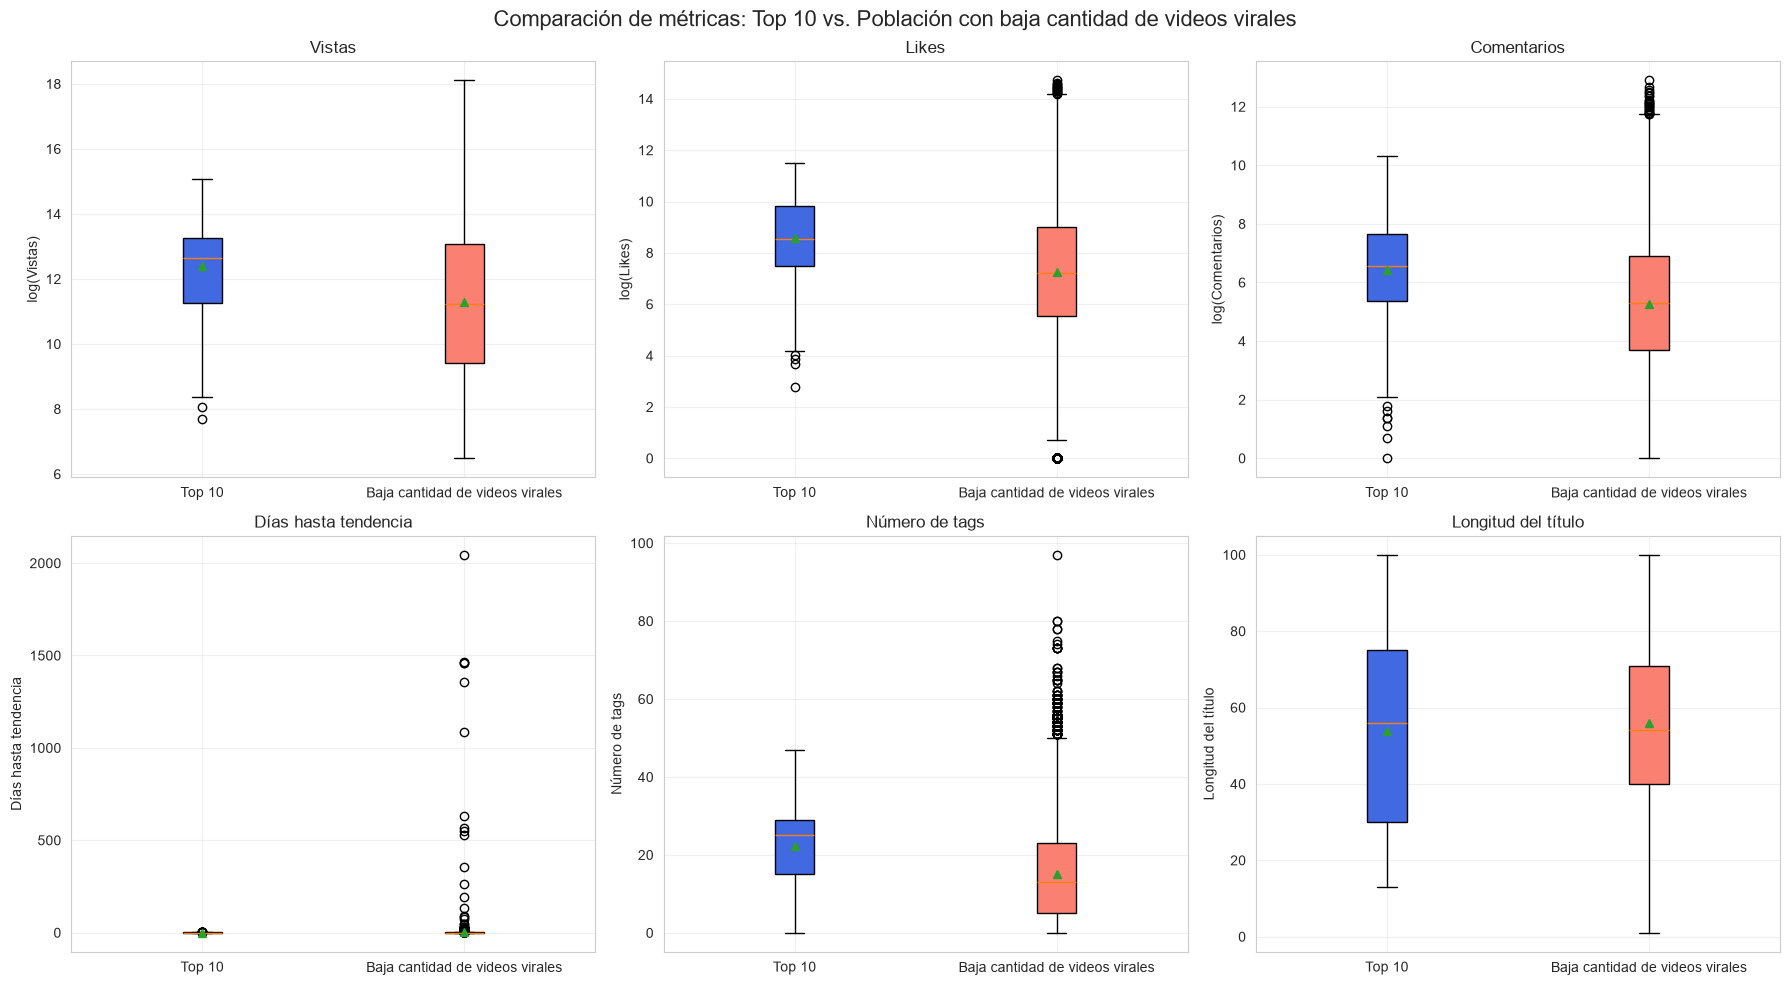

In [18]:
# --- Separar los dos grupos ---
channel_freq = df['channel_title'].value_counts()

# Grupo A: Top 10 canales (alta frecuencia)
top_10_channels = channel_freq.head(10).index.tolist()

# Grupo B: Canales con frecuencia entre 1 y 5 (baja frecuencia)
low_freq_channels = channel_freq[(channel_freq >= 1) & (channel_freq <= 5)].index.tolist()

# --- Filtrar el dataframe para cada grupo ---
df_top = df[df['channel_title'].isin(top_10_channels)]
df_low = df[df['channel_title'].isin(low_freq_channels)]

# --- Visualización comparativa con boxplots (escala logarítmica) ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
metrics_plot = ['views', 'likes', 'comment_count', 'days_to_trend', 'num_tags', 'title_length']
titles = ['Vistas', 'Likes', 'Comentarios', 'Días hasta tendencia', 'Número de tags', 'Longitud del título']

for i, (metric, title) in enumerate(zip(metrics_plot, titles)):
    row = i // 3
    col = i % 3
    ax = axes[row, col]
    
    # Datos para el boxplot (usamos logaritmo para vistas/likes/comentarios porque tienen cola larga)
    if metric in ['views', 'likes', 'comment_count']:
        data_top = np.log1p(df_top[metric])
        data_low = np.log1p(df_low[metric])
        ylabel = f'log({title})'
    else:
        data_top = df_top[metric]
        data_low = df_low[metric]
        ylabel = title
    
    # Crear el boxplot
    bp = ax.boxplot([data_top, data_low], tick_labels=['Top 10', 'Baja cantidad de videos virales'], 
                    patch_artist=True, showmeans=True)
    # Colorear
    bp['boxes'][0].set_facecolor('royalblue')
    bp['boxes'][1].set_facecolor('salmon')
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)

plt.suptitle('Comparación de métricas: Top 10 vs. Población con baja cantidad de videos virales', fontsize=16)
plt.tight_layout()
plt.show()

### ¿Qué Canales de YouTube son tendencia más frecuentemente? ¿Y cuáles con menos frecuencia?

Para abordar esta pregunta, se analizó la frecuencia de aparición de los 6,085 canales únicos presentes en el dataset de Alemania.

#### Distribución general de frecuencias
La Figura (2.relative) muestra la distribución de frecuencias. Se observa una marcada ley de potencia (cola larga). El 40.8% de los canales (2,485) aparecen en la lista de tendencias una sola vez, y el 76.7% (4,668) aparecen 5 veces o menos. Esto implica que solo el 23.3% restante (1,417 canales) logran un éxito sostenido con más de 5 apariciones. Este hallazgo evidencia la alta rotación de la plataforma, donde la gran mayoría de los creadores apenas logran una incursión efímera en la popularidad.

#### Canales con mayor frecuencia (Top 10)
Los canales que lideran en frecuencia son, en su mayoría, creadores de contenido masivo y diario, pertenecientes a las categorías de "Entretenimiento" y "Música" (ej. inscope21, BangerChannel, Rezo, etc.). (Figura (1.relative)) Estos canales presentan una mediana de 0 días hasta llegar a tendencia, lo que indica que su audiencia fiel los impulsa al ranking el mismo día de la publicación.

#### Análisis comparativo: Consistencia vs. Viralidad (Hallazgo clave)
Al contrastar el Top 10 con el resto de canales (especialmente aquellos con baja frecuencia), se identifica un fenómeno contraintuitivo pero revelador: aunque los canales del Top 10 son más frecuentes, no necesariamente tienen las mayores vistas por video. Los canales de baja frecuencia suelen estar asociados a eventos puntuales de gran impacto mediático, como estrenos musicales, tráilers de cine o series de televisión de gran audiencia (ej. Ed Sheeran, Dolunay). Estos videos pueden acumular millones de vistas en una sola publicación, superando ampliamente las vistas promedio de los canales "frecuentes".

Sin embargo, la clave del éxito sostenido no reside en el pico de vistas, sino en la regularidad. Los canales del Top 10 promedian más de 150 apariciones en el período analizado, demostrando que la capacidad de generar engagement constante y predecible es el verdadero motor de la permanencia en tendencia. Esta diferencia se visualiza claramente en los boxplots de la Figura (3.relative), donde se aprecia que, si bien el Top 10 tiene una mediana de vistas ligeramente inferior a la del resto (debido a la presencia de outliers virales en el resto), su consistencia es inigualable.

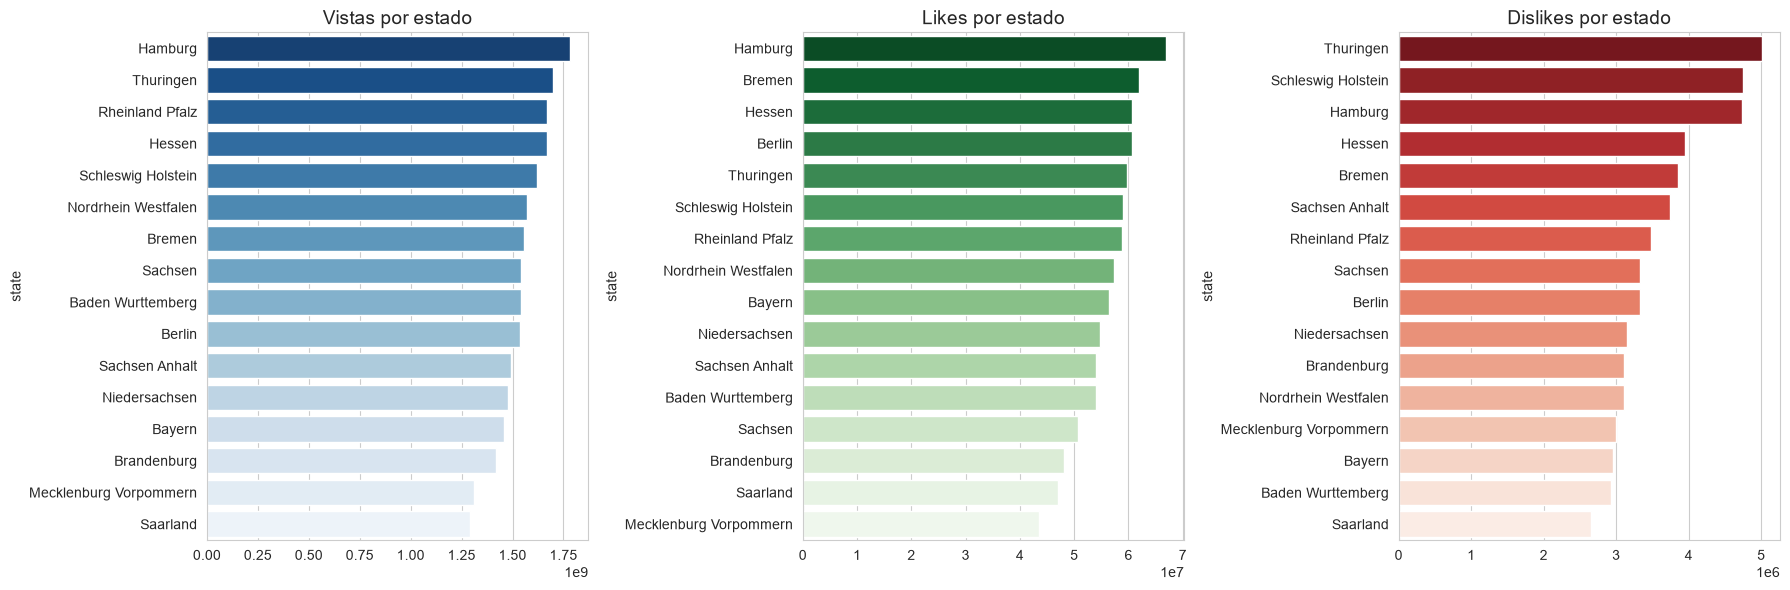

In [23]:
# --- Q7: Estados con mayor número de vistas, likes y dislikes ---
# (Nota: los estados son aleatorios según el enunciado, pero igual los graficamos)
state_views = df.groupby('state')['views'].sum().sort_values(ascending=False).head(18)
state_likes = df.groupby('state')['likes'].sum().sort_values(ascending=False).head(18)
state_dislikes = df.groupby('state')['dislikes'].sum().sort_values(ascending=False).head(18)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sns.barplot(x=state_views.values, y=state_views.index, hue=state_views.index, ax=axes[0], palette='Blues_r', legend=False)
axes[0].set_title('Vistas por estado', fontsize=14)
sns.barplot(x=state_likes.values, y=state_likes.index, hue=state_likes.index, ax=axes[1], palette='Greens_r', legend=False)
axes[1].set_title('Likes por estado', fontsize=14)
sns.barplot(x=state_dislikes.values, y=state_dislikes.index, hue=state_dislikes.index, ax=axes[2], palette='Reds_r', legend=False)
axes[2].set_title('Dislikes por estado', fontsize=14)
plt.tight_layout()
plt.show()

### Gráfico en mapa

In [20]:
import plotly.express as px

In [ ]:
state_agg = df.groupby('state').agg({
    'views': 'sum',
    'likes': 'sum',
    'dislikes': 'sum'
}).reset_index()

state_coords = df.groupby('state')[['lat', 'lon']].first().reset_index()
state_data = state_agg.merge(state_coords, on='state')


In [ ]:
def create_metric_map(data, metric_column, title, color_scale, size_max=15, use_log=False):
    """
    Crea un mapa de burbujas.
    - size_max: tamaño máximo de la burbuja (reducido para que no se solapen)
    - use_log: si True, aplica logaritmo al tamaño para comprimir diferencias extremas
    """
    # Copiar datos para no modificar el original
    plot_data = data.copy()
    
    # Si usamos log, creamos una columna auxiliar para el tamaño
    if use_log:
        plot_data['size'] = np.log1p(plot_data[metric_column])
        size_col = 'size'
    else:
        size_col = metric_column
    
    fig = px.scatter_geo(
        plot_data,
        lat='lat',
        lon='lon',
        size=size_col,
        hover_name='state',
        color=metric_column,
        color_continuous_scale=color_scale,
        title=title,
        size_max=size_max,   # <<--- AJUSTA ESTE VALOR (15, 12, 10, etc.)
        projection='natural earth'
    )
    
    # Ajustar el zoom y la apariencia
    fig.update_geos(
        projection_type="natural earth",
        center=dict(lat=51, lon=10),
        projection_scale=15,        # Zoom sobre Alemania
        showcoastlines=True,
        coastlinecolor="Black",
        showland=True,
        landcolor="lightgray",
        showocean=True,
        oceancolor="lightblue",
        showcountries=True,
        countrycolor="Black"
    )
    
    fig.update_layout(
        margin={"r": 0, "t": 50, "l": 0, "b": 0},
        legend_title_text='Total Acumulado'
    )
    
    return fig

# --- 3. Generar los 3 mapas ---

fig_views = create_metric_map(state_data, 'views', 'Total de Vistas por Estado', 'Blues', size_max=12, use_log=False)
fig_views.show()
fig_views.write_image("../img/state_views.png")

fig_likes = create_metric_map(state_data, 'likes', 'Total de Likes por Estado', 'Greens', size_max=12, use_log=False)
fig_likes.show()
fig_likes.write_image("../img/state_likes.png")

fig_dislikes = create_metric_map(state_data, 'dislikes', 'Total de Dislikes por Estado', 'Reds', size_max=12, use_log=False)
fig_dislikes.show()
fig_dislikes.write_image("../img/state_dislikes.png")

In [29]:
import scipy.stats as stats
from scipy.stats import spearmanr, mannwhitneyu

# --- Asegurar que los grupos Top 10 están definidos (de la Q6) ---
# Si no lo tienes guardado, recalcula:
channel_freq = df['channel_title'].value_counts()
top_10_channels = channel_freq.head(10).index.tolist()
df['is_top_10'] = df['channel_title'].isin(top_10_channels)

# --- 1. Calcular la tasa de aprobación ---
# Fórmula: likes / (likes + dislikes). Si el denominador es 0, el resultado es np.nan.
df['tasa_aprobacion'] = df['likes'] / (df['likes'] + df['dislikes'])
# Reemplazar posibles infinitos (si likes=0 y dislikes=0, improbable pero por seguridad)
df['tasa_aprobacion'] = df['tasa_aprobacion'].replace([np.inf, -np.inf], np.nan)

# Verificar cuántos NaN quedaron (deberían ser muy pocos o ninguno)
print(f"NaN en tasa_aprobacion: {df['tasa_aprobacion'].isna().sum()}")

# --- 2. Estadísticos descriptivos por grupo ---
desc_stats = df.groupby('is_top_10')['tasa_aprobacion'].agg([
    ('count', 'count'),
    ('mean', 'mean'),
    ('median', 'median'),
    ('std', 'std'),
    ('min', 'min'),
    ('Q1', lambda x: x.quantile(0.25)),
    ('Q3', lambda x: x.quantile(0.75)),
    ('max', 'max')
]).round(4)

print("\n=== ESTADÍSTICOS DESCRIPTIVOS - TASA DE APROBACIÓN ===")
print(desc_stats)

# --- 3. Estadísticos descriptivos para comment_count (secundario) ---
desc_comments = df.groupby('is_top_10')['comment_count'].agg([
    ('count', 'count'),
    ('mean', 'mean'),
    ('median', 'median'),
    ('std', 'std'),
    ('min', 'min'),
    ('Q1', lambda x: x.quantile(0.25)),
    ('Q3', lambda x: x.quantile(0.75)),
    ('max', 'max')
]).round(2)

print("\n=== ESTADÍSTICOS DESCRIPTIVOS - COMMENT_COUNT ===")
print(desc_comments)


NaN en tasa_aprobacion: 677

=== ESTADÍSTICOS DESCRIPTIVOS - TASA DE APROBACIÓN ===
           count    mean  median     std     min      Q1      Q3  max
is_top_10                                                            
False      38446  0.9167  0.9555  0.1100  0.0000  0.9018  0.9787  1.0
True        1717  0.9541  0.9696  0.0503  0.1638  0.9438  0.9800  1.0

=== ESTADÍSTICOS DESCRIPTIVOS - COMMENT_COUNT ===
           count     mean  median       std  min     Q1      Q3      max
is_top_10                                                               
False      39123  2843.46   366.0  17829.58    0   75.0  1342.5  1084435
True        1717  1473.33   714.0   2062.44    0  210.0  2099.0    29907


C:\Users\Usuario\AppData\Local\Temp\ipykernel_25276\374392842.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  violin_parts = sns.violinplot(
C:\Users\Usuario\AppData\Local\Temp\ipykernel_25276\374392842.py:9: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  violin_parts = sns.violinplot(
C:\Users\Usuario\AppData\Local\Temp\ipykernel_25276\374392842.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['Resto de canales', 'Top 10 canales'])


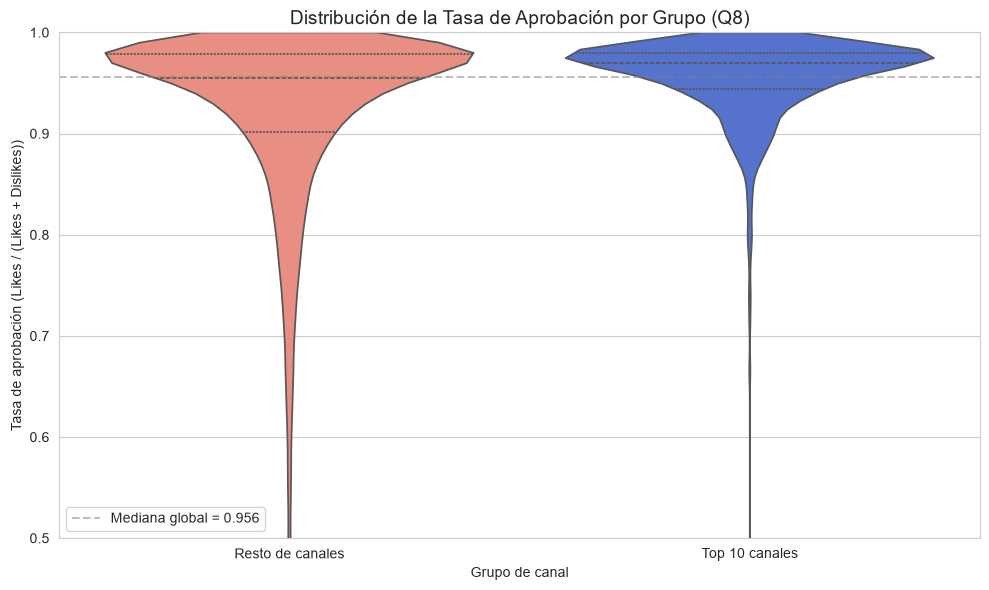

In [31]:
# Asegurar que los datos estén listos (df con 'is_top_10', 'tasa_aprobacion', 'comment_count')
# Filtrar NaN en tasa_aprobacion para los gráficos
df_plot = df.dropna(subset=['tasa_aprobacion'])

# --- GRÁFICO 1: VIOLIN PLOT (Tasa de Aprobación) ---
fig, ax = plt.subplots(figsize=(10, 6))

# Paletas para mantener consistencia con Q6 (salmon = Resto, royalblue = Top 10)
violin_parts = sns.violinplot(
    x='is_top_10', 
    y='tasa_aprobacion', 
    data=df_plot,
    palette=['salmon', 'royalblue'],
    inner='quartile',  # Muestra la mediana y los cuartiles dentro del violín
    cut=0,             # No extiende más allá de los datos reales
    scale='width'      # Cada violín tiene el mismo ancho máximo
)

# Personalizar etiquetas
ax.set_xticklabels(['Resto de canales', 'Top 10 canales'])
ax.set_title('Distribución de la Tasa de Aprobación por Grupo (Q8)', fontsize=14)
ax.set_xlabel('Grupo de canal')
ax.set_ylabel('Tasa de aprobación (Likes / (Likes + Dislikes))')
ax.set_ylim(0.5, 1.0)  # Ajustar el eje Y para ver mejor las diferencias

# Añadir línea horizontal en la mediana global (opcional)
global_median = df_plot['tasa_aprobacion'].median()
ax.axhline(y=global_median, color='gray', linestyle='--', alpha=0.5, label=f'Mediana global = {global_median:.3f}')
ax.legend()

plt.tight_layout()
plt.show()


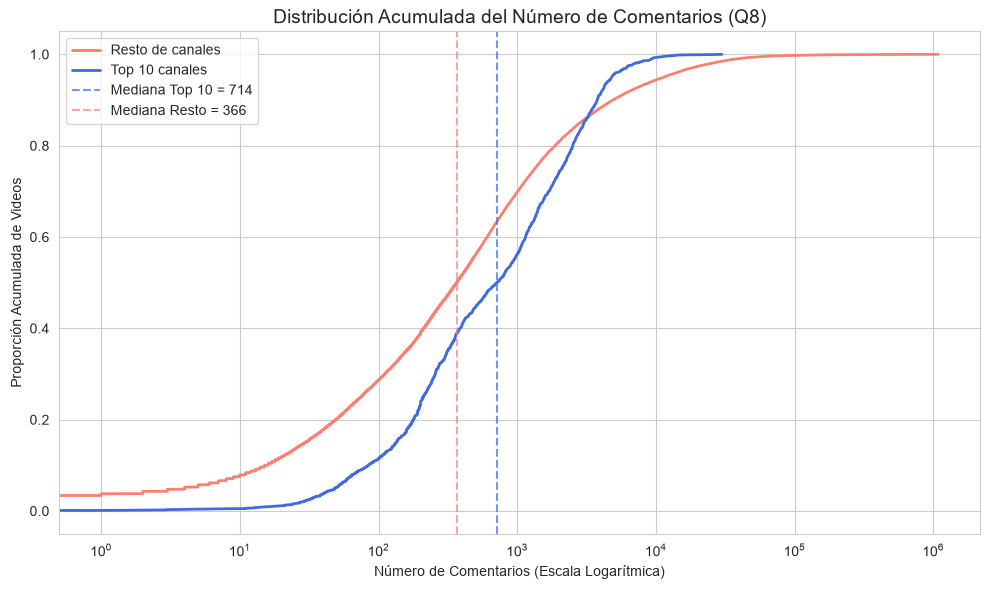

In [32]:
# --- GRÁFICO 2: ECDF (Número de Comentarios) ---
# Función para calcular la ECDF (Curva de Distribución Acumulada)
def ecdf(data):
    x = np.sort(data)
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y

fig, ax = plt.subplots(figsize=(10, 6))

# Calcular ECDF para cada grupo
top_comments = df[df['is_top_10']]['comment_count']
rest_comments = df[~df['is_top_10']]['comment_count']

x_top, y_top = ecdf(top_comments)
x_rest, y_rest = ecdf(rest_comments)

# Graficar en escala logarítmica (esencial para ver la cola larga)
ax.plot(x_rest, y_rest, label='Resto de canales', color='salmon', linewidth=2)
ax.plot(x_top, y_top, label='Top 10 canales', color='royalblue', linewidth=2)

# Personalizar
ax.set_xscale('log')  # Escala logarítmica para comprimir la cola larga
ax.set_title('Distribución Acumulada del Número de Comentarios (Q8)', fontsize=14)
ax.set_xlabel('Número de Comentarios (Escala Logarítmica)')
ax.set_ylabel('Proporción Acumulada de Videos')
ax.legend()

# Añadir líneas verticales en las medianas para referencia
med_top = top_comments.median()
med_rest = rest_comments.median()
ax.axvline(x=med_top, color='royalblue', linestyle='--', alpha=0.7, label=f'Mediana Top 10 = {med_top:.0f}')
ax.axvline(x=med_rest, color='salmon', linestyle='--', alpha=0.7, label=f'Mediana Resto = {med_rest:.0f}')
ax.legend()

plt.tight_layout()
plt.show()

In [30]:
# --- 4. Test de Mann-Whitney U (Hipótesis: Top 10 tiene mayor tasa de aprobación) ---
# Separar los grupos (eliminando NaN)
top_approval = df[df['is_top_10']]['tasa_aprobacion'].dropna()
rest_approval = df[~df['is_top_10']]['tasa_aprobacion'].dropna()

# Test unilateral (alternativa: la distribución de Top 10 es estocásticamente mayor)
u_stat, p_value = mannwhitneyu(top_approval, rest_approval, alternative='greater')

print("\n=== TEST DE MANN-WHITNEY U ===")
print(f"Estadístico U: {u_stat:.4f}")
print(f"P-valor: {p_value:.6f}")
if p_value < 0.05:
    print("Conclusión: Rechazamos H0. El Top 10 tiene una tasa de aprobación significativamente MAYOR que el resto (p < 0.05).")
else:
    print("Conclusión: No se rechaza H0. No hay evidencia suficiente para afirmar que el Top 10 tenga mayor tasa de aprobación.")

# --- 5. Correlaciones de Spearman ---
# Correlación entre tasa de aprobación y comment_count
corr_comments, p_comments = spearmanr(df['tasa_aprobacion'], df['comment_count'], nan_policy='omit')
# Correlación entre tasa de aprobación y views
corr_views, p_views = spearmanr(df['tasa_aprobacion'], df['views'], nan_policy='omit')
# Correlación entre tasa de aprobación y pertenencia al Top 10
corr_top10, p_top10 = spearmanr(df['tasa_aprobacion'], df['is_top_10'], nan_policy='omit')

print("\n=== CORRELACIONES DE SPEARMAN ===")
print(f"Tasa aprobación vs. comment_count: rho = {corr_comments:.4f} (p = {p_comments:.6f})")
print(f"Tasa aprobación vs. views: rho = {corr_views:.4f} (p = {p_views:.6f})")
print(f"Tasa aprobación vs. is_top_10: rho = {corr_top10:.4f} (p = {p_top10:.6f})")

# --- 6. (Opcional) Tamaño del efecto para Mann-Whitney (r = Z / sqrt(N)) ---
# Se puede calcular para dar contexto, pero no es obligatorio.
from scipy.stats import norm
z_score = (u_stat - (len(top_approval) * len(rest_approval) / 2)) / np.sqrt((len(top_approval) * len(rest_approval) * (len(top_approval) + len(rest_approval) + 1)) / 12)
r_effect = abs(z_score) / np.sqrt(len(top_approval) + len(rest_approval))
print(f"\nTamaño del efecto (r): {r_effect:.4f} (interpretación: 0.1=pequeño, 0.3=mediano, 0.5=grande)")


=== TEST DE MANN-WHITNEY U ===
Estadístico U: 38944424.0000
P-valor: 0.000000
Conclusión: Rechazamos H0. El Top 10 tiene una tasa de aprobación significativamente MAYOR que el resto (p < 0.05).

=== CORRELACIONES DE SPEARMAN ===
Tasa aprobación vs. comment_count: rho = 0.1144 (p = 0.000000)
Tasa aprobación vs. views: rho = -0.0551 (p = 0.000000)
Tasa aprobación vs. is_top_10: rho = 0.0630 (p = 0.000000)

Tamaño del efecto (r): 0.0630 (interpretación: 0.1=pequeño, 0.3=mediano, 0.5=grande)


### ¿Los videos en tendencia son los que mayor cantidad de comentarios positivos reciben?

Para abordar esta pregunta, se utilizó la tasa de aprobación (likes / (likes + dislikes)) como proxy de "comentarios positivos", comparando los canales del Top 10 (mayor frecuencia en tendencia) versus el resto de canales.

#### Resultados

Ambos grupos presentan tasas de aprobación muy altas (mediana del Top 10 = 0.9696, mediana del resto = 0.9555). La prueba de Mann-Whitney U indicó que la diferencia es estadísticamente significativa (p < 0.001), pero el tamaño del efecto es pequeño (r = 0.063), lo que sugiere que la diferencia práctica es mínima. La verdadera distinción radica en la consistencia: el Top 10 tiene una desviación estándar mucho menor (0.050 vs. 0.110), lo que indica que estos canales mantienen una alta aprobación de forma más uniforme, mientras que el resto presenta mayor variabilidad (con picos de aprobación igualmente altos, pero también videos menos aceptados).

En cuanto al volumen de comentarios, la mediana del Top 10 (714) es significativamente superior a la del resto (366), lo que refleja una mayor capacidad de generar conversación en sus videos. Sin embargo, la media del resto es superior debido a videos virales atípicos con comentarios masivos (máximo de 1,084,435 frente a 29,907 del Top 10).

#### Visualización de resultados

Para complementar el análisis numérico, se construyeron dos visualizaciones clave (Figura X y Figura Y). La Figura X (gráfico de violín) muestra la distribución de la tasa de aprobación por grupo. Se observa que el Top 10 presenta una distribución más concentrada y estrecha (alta consistencia), mientras que el Resto muestra una cola izquierda más pronunciada (mayor variabilidad y riesgo de baja aprobación). Este hallazgo confirma que la ventaja del Top 10 no reside en alcanzar picos de aprobación más altos (ambos grupos llegan a 1.0), sino en evitar caídas en la aceptación del público.

La Figura Y (curva de distribución acumulada del número de comentarios en escala logarítmica) revela una dinámica complementaria: la curva del Resto asciende más rápidamente en los valores bajos (lo que explica su mediana inferior de 366 comentarios), pero se extiende considerablemente más hacia la derecha, evidenciando la existencia de videos virales atípicos que generan cientos de miles de comentarios y elevan su media por encima de la del Top 10. Por el contrario, la curva del Top 10 es más "corta" y desplazada a la derecha en su inicio, reflejando que sus videos típicos generan más comentarios (mediana de 714), pero sin alcanzar los picos extremos del Resto.

#### Conclusión

Los videos en tendencia, en general, reciben una alta aprobación, pero los canales que logran permanecer en el ranking (Top 10) no son necesariamente los que tienen la mayor aprobación pico, sino aquellos que generan un engagement positivo consistente y estable, complementado con un mayor volumen de comentarios en sus videos típicos.

In [33]:
df.to_csv("../data/DEvideos_EDA.csv", index=False)